In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np

current_dir = Path('.')
experiments_dir = current_dir / '../data/experiments'
dpi = 150

In [2]:
def draw_swe_map(ax, data, label, vmin, vmax, cmap='PiYG'):
    minlon, minlat, maxlon, maxlat = 27, 50, 56, 65
    lons = np.arange(minlon, maxlon+0.1, 0.25)
    lats = np.arange(minlat, maxlat+0.1, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    ax.set_extent([minlon, maxlon, minlat, maxlat], ccrs.PlateCarree())
    
    mesh = ax.pcolormesh(lon_grid, lat_grid, data, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading='gouraud', rasterized=True)
    
    ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)
    gdf = gpd.read_file('../data/raw/time_invariant/ne_10m_admin_1_states_provinces.zip')
    russia_regions = gdf[gdf['admin'] == 'Russia']
    ax.add_geometries(russia_regions.geometry, crs=ccrs.PlateCarree(),
                      edgecolor='k', facecolor='none', linewidth=0.5, linestyle=':', zorder=3)
    ax.text(0.03, 0.9, label, transform=ax.transAxes, fontsize=14)
    return mesh

def plot_swe_corr(datasets, name):
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), gridspec_kw={'wspace': 0.02, 'hspace': 0.02},
                        subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    labels = ['a)', 'б)', 'в)', 'г)']

    meshes = []
    for i, ax in enumerate(axes):
        meshes.append(draw_swe_map(ax, datasets[i], labels[i], -0.5, 0.5))

    fig.subplots_adjust(bottom=0.13)
    cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
    cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation='horizontal', ticks=np.arange(-0.5, 0.51, 0.1))
    plt.savefig(f'../figures/article/{name}.png', dpi=dpi, bbox_inches='tight')
    plt.show()

(61, 117)


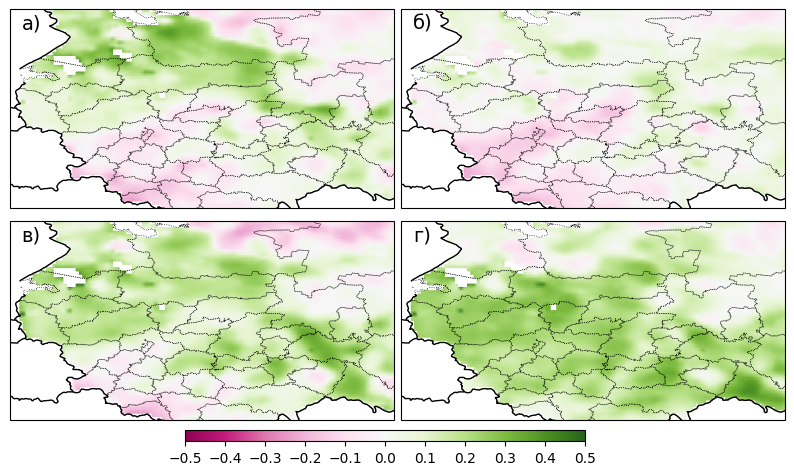

(61, 117)


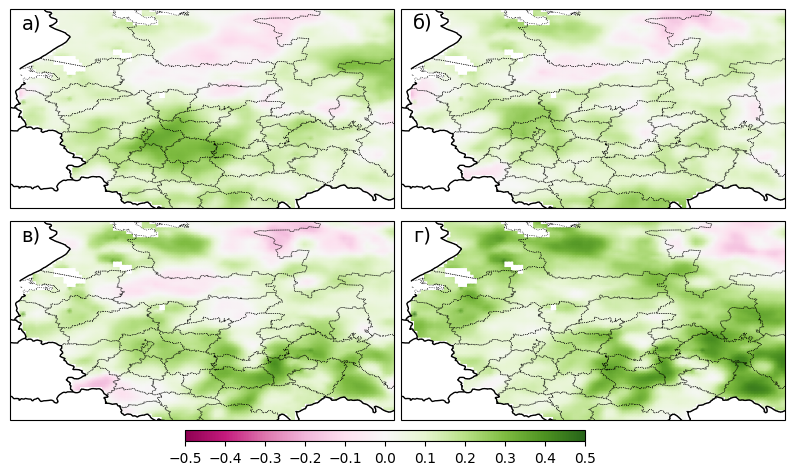

In [3]:
for period, name in [('spring', 'img1'), ('autum', 'img2')]:
    base_corr_df = pd.read_csv(experiments_dir / f'swe_etr_base_point_{period}_corr.csv').drop(columns=['lat']).to_numpy()
    print(base_corr_df.shape)
    datasets = []
    for model in ['point', 'seq', 'map', 'seqmap_v3']:
        corr_df = pd.read_csv(experiments_dir / f'swe_etr_{model}_{period}_corr.csv').drop(columns=['lat']).to_numpy()
        datasets.append(corr_df - base_corr_df)
    plot_swe_corr(datasets, name)

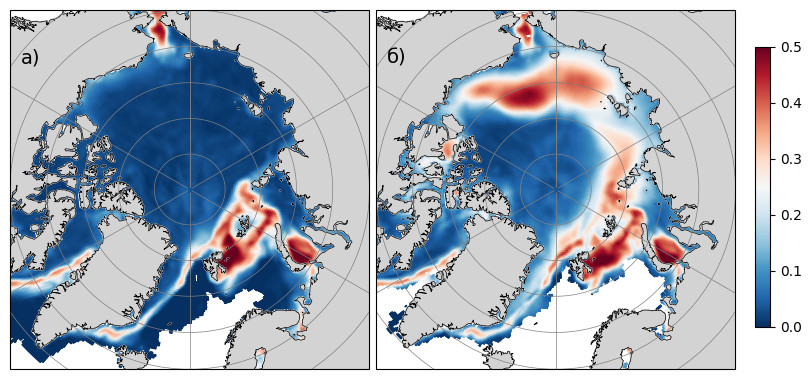

In [24]:
def draw_ice_map(ax, data, label, cmap='RdBu_r'):
    lats = np.arange(40, 90.25, 0.25)
    lons = np.arange(-180, 180, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    ax.set_extent([-180, 180, 65, 90], ccrs.PlateCarree())
    mesh = ax.pcolormesh(lon_grid, lat_grid, data, transform=ccrs.PlateCarree(), cmap=cmap,
                     vmin=0, vmax=0.5, shading='gouraud', rasterized=True)
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    gl = ax.gridlines(linewidth=0.5, color='gray')
    ax.text(0.03, 0.85, label, transform=ax.transAxes, fontsize=14)
    return mesh

fig, axes = plt.subplots(1, 2, figsize=(10, 5.6), gridspec_kw={'wspace': 0.02, 'hspace': 0.02},
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})

meshes = []
for ax, label, season in zip(axes, ['а)', 'б)'], ['spring', 'autum']):
    base_rmse_df = pd.read_csv(experiments_dir / f'aice_base_{season}_rmse.csv').drop(columns=['lat']).to_numpy()
    meshes.append(draw_ice_map(ax, base_rmse_df, label))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.25, 0.015, 0.5])
cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation='vertical', ticks=np.arange(0, 0.51, 0.1))

plt.savefig(f'../figures/article/img1.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [2]:
from models import BaseModel, LinearRegression, load_nn
from train import load_dataset, evaluate

for season, season_num in [('spring', 4), ('autum', 5)]:
    dsTest = load_dataset(f"swe_{season_num}_2_3_point_test")
    for ds_name, model_name in [('point', 'base'), ('point', 'lr'), ('point', 'mlp'), ('seq', 'tcn'), ('map', 'cnn'), ('seqmap', 'seqmap')]:
        if model_name == 'base':
            model = BaseModel()
            model.fit(dsTest)
        elif model_name == 'lr':
            dsTrain = load_dataset(f"swe_{season_num}_2_3_point_train")
            model = LinearRegression()
            model.fit(dsTrain)
        else:
            dsTest = load_dataset(f"swe_{season_num}_2_3_{ds_name}_test")
            model = load_nn(f"../data/experiments/swe_etr_{model_name}_{season}")
        try:
            print(season, model_name, evaluate(dsTest, model).iloc[0]['loss'])
        except:
            dsTest = load_dataset(f"../experiments/swe_etr_{model_name}_{season}_ds")
            print(season, model_name, evaluate(dsTest, model).iloc[0]['loss'])            

spring base 0.2244
spring lr 0.2432
spring mlp 0.3296
spring tcn 0.3326
spring cnn 0.373
spring seqmap 0.4265
autum base 0.2484
autum lr 0.2831
autum mlp 0.3037
autum tcn 0.3056
autum cnn 0.3226
autum seqmap 0.3274


In [45]:
dsTest = load_dataset(f"swe_5_2_3_point_train")

In [27]:
dsTest.variables

['swe',
 'cld',
 'olr',
 'prec',
 'ps',
 'rq2',
 't2',
 't2max',
 't2min',
 't850',
 'u850',
 'uv10',
 'ww',
 'z',
 'sdor',
 'cos_lat',
 'sin_lon',
 'cos_lon',
 'cos_period',
 'sin_period',
 'year']

In [46]:
import torch
from train import loss

ds = dsTest
model = BaseModel()
model.fit(ds)

y_true, y_pred, lat, years = [], [], [], []

for X_batch, y_batch, lat_batch in ds.loader:
    y_pred.append(model.predict(X_batch))
    if ds.loader_type == 'sequence' or ds.loader_type == 'sequence_map':
        y_true.append(y_batch[-1, :])
        lat.append(lat_batch[-1, :])
    elif ds.loader_type == 'point' or ds.loader_type == 'map':
        y_true.append(y_batch)
        lat.append(lat_batch)
        years.append(X_batch[:, -1])
    if len(y_pred[-1].shape) < len(y_true[-1].shape):
        y_pred[-1] = y_pred[-1].unsqueeze(0)

y_true, y_pred, lat, years = torch.cat(y_true), torch.cat(y_pred), torch.cat(lat), torch.cat(years)

In [47]:
def error_by_year(y_true, y_pred, lat, years):
    errors = {}
    for year in torch.unique(years):
        mask = years == year
        errors[year.item()] = loss('swe', y_true[mask], y_pred[mask], lat[mask]).item()
    return errors
errors = error_by_year(y_true, y_pred, lat, years)

In [48]:
errors

{-1.399999976158142: 0.10946717858314514,
 -1.2999999523162842: 0.20096509158611298,
 -1.2000000476837158: 0.3098098933696747,
 -1.100000023841858: 0.2588050961494446,
 -1.0: -0.011314849369227886,
 -0.8999999761581421: 0.1238705962896347,
 -0.800000011920929: 0.09395769238471985,
 -0.699999988079071: -0.19284459948539734,
 -0.6000000238418579: 0.1374894380569458,
 -0.5: 0.005890167783945799,
 -0.4000000059604645: -0.03386940434575081,
 -0.30000001192092896: -0.42280781269073486,
 -0.20000000298023224: 0.139750674366951,
 -0.10000000149011612: 0.10931312292814255,
 0.0: 0.20220763981342316,
 0.10000000149011612: 0.2558215260505676,
 0.20000000298023224: -0.10003591328859329,
 0.30000001192092896: 0.27452123165130615,
 0.4000000059604645: -0.10859975218772888,
 0.5: -0.1391228884458542,
 0.6000000238418579: 0.16361196339130402,
 0.699999988079071: 0.12112218141555786,
 0.800000011920929: 0.08108409494161606,
 0.8999999761581421: 0.11466279625892639}